In [13]:
import os
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, Phylo, Entrez
from Bio.SearchIO.HmmerIO.hmmer3_domtab import Hmmer3DomtabHmmqueryParser

cwd = os.getcwd()
if cwd.endswith('Halocins'):
    os.chdir('../..')
    cwd = os.getcwd()

from src.tree.itol_annotation import itol_labels, itol_color_strip_annotations

In [10]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=2)
palette = sns.color_palette().as_hex()

In [11]:
data_folder = Path('data/amp_db/')
assert data_folder.is_dir()

staphc8_folder = Path('data/amp_db/Halocins/Halocin_C8')
assert staphc8_folder.is_dir()

halc8_out = Path('data/outputs/amp_db/Halocins/Halocin_C8')


In [12]:
gtdb_metadata = pd.read_csv(data_folder / 'gtdb_metadata.csv.gz', index_col='ncbi_accession')
gtdb_metadata.head()

,accession,ambiguous_bases,checkm_completeness,checkm_contamination,checkm_marker_count,checkm_marker_lineage,checkm_marker_set_count,checkm_strain_heterogeneity,coding_bases,coding_density,...,trna_aa_count,trna_count,trna_selenocysteine_count,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species
ncbi_accession,,,,,,,,,,,,,,,,,,,,,
GCA_000007325.1,GB_GCA_000007325.1,1,99.95,0.00,149,k__Bacteria (UID2329),89,0.0,1973459,90.754610,...,19,47,0,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Fusobacterium,Fusobacterium nucleatum
GCA_000008085.1,GB_GCA_000008085.1,0,73.13,0.00,149,k__Archaea (UID2),107,0.0,462902,94.299480,...,18,39,0,Archaea,Nanoarchaeota,Nanoarchaeia,Nanoarchaeales,Nanoarchaeaceae,Nanoarchaeum,Nanoarchaeum equitans
GCA_000008885.1,GB_GCA_000008885.1,0,100.00,0.00,134,k__Bacteria (UID2495),80,0.0,617456,87.831079,...,19,34,0,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Wigglesworthia,Wigglesworthia glossinidia_A
GCA_000009845.1,GB_GCA_000009845.1,3,98.57,0.00,121,k__Bacteria (UID2328),70,0.0,675273,79.155941,...,19,32,0,Bacteria,Bacillota,Bacilli,Acholeplasmatales,Acholeplasmataceae,Phytoplasma,Phytoplasma sp000009845
GCA_000010565.1,GB_GCA_000010565.1,0,100.00,0.63,295,p__Firmicutes (UID1022),158,0.0,2608397,86.217312,...,19,51,1,Bacteria,Bacillota_B,Desulfotomaculia,Desulfotomaculales,Pelotomaculaceae,Pelotomaculum,Pelotomaculum thermopropionicum


In [530]:
amp_df = pd.read_csv(data_folder / 'amp_db_screening_results_with_tax.csv.gz').drop(columns=['ncbi_accession'])

uniprot_mapping = pd.read_csv(data_folder / 'pg_hydrolase' / 'db_prokaryotes_UniProtKB_good_match.csv')
uniprot_mapping['assembly_accession'] = uniprot_mapping['query'].apply(lambda q: q.split('@')[1])
uniprot_mapping['protein_id'] = uniprot_mapping['query'].apply(lambda q: q.split('@')[0])
uniprot_mapping.head()

amp_df = pd.merge(
    amp_df,
    uniprot_mapping.rename(columns={'target': 'uniprot_id'})[['uniprot_id', 'protein_id']],
    on='protein_id',
    how='left',
)

amp_df.head()

,assembly_accession,protein_id,amp_id,amp_desc,evalue,bitscore,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,uniprot_id
0,GCA_000007325.1,AAL94370.1,pg_hydrolase,Amidase_2+PG_binding_1,1.150000e-08,61.95,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Fusobacterium,Fusobacterium nucleatum,Fusobacterium nucleatum subsp. nucleatum ATCC ...,Q8RGW3
1,GCA_000007325.1,AAL94673.1,pg_hydrolase,Peptidase_M23+LysM,6.500000e-08,64.00,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Fusobacterium,Fusobacterium nucleatum,Fusobacterium nucleatum subsp. nucleatum ATCC ...,Q8RG41
2,GCA_000008885.1,BAC24414.1,pg_hydrolase,Amidase_3+AMIN,3.900000e-15,106.70,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Wigglesworthia,Wigglesworthia glossinidia_A,Wigglesworthia glossinidia endosymbiont of Glo...,Q8D2T6
3,GCA_000010565.1,BAF58967.1,pg_hydrolase,Amidase_3+AMIN,6.000000e-15,121.55,Bacteria,Bacillota_B,Desulfotomaculia,Desulfotomaculales,Pelotomaculaceae,Pelotomaculum,Pelotomaculum thermopropionicum,Pelotomaculum thermopropionicum SI,A5D461
4,GCA_000010565.1,BAF60354.1,pg_hydrolase,Amidase_2+LysM,6.000135e-15,59.45,Bacteria,Bacillota_B,Desulfotomaculia,Desulfotomaculales,Pelotomaculaceae,Pelotomaculum,Pelotomaculum thermopropionicum,Pelotomaculum thermopropionicum SI,A5D090


In [531]:
halocins_df = amp_df[amp_df['amp_id'].str.contains('Halocin')]
halocins_df['amp_id'].unique()

array(['Halocin_C8', 'Halocin_H4', 'Halocin_S8'], dtype=object)

In [532]:
phylum_view = halocins_df[
    ['domain', 'gtdb_phylum', 'amp_id', 'protein_id']
].groupby(
    ['domain', 'gtdb_phylum', 'amp_id']
).nunique().sort_values('protein_id', ascending=False)
phylum_view

protein_id
domain   gtdb_phylum         amp_id                
Archaea  Halobacteriota      Halocin_C8          58
Bacteria Bacillota           Halocin_C8           9
Archaea  Halobacteriota      Halocin_H4           7
         Thermoplasmatota    Halocin_C8           5
         Halobacteriota      Halocin_S8           4
Bacteria Chloroflexota       Halocin_C8           4
Archaea  Methanobacteriota_B Halocin_C8           2
         Thermoproteota      Halocin_C8           1
Bacteria Actinomycetota      Halocin_C8           1
         Bacillota_A         Halocin_H4           1
         Desulfobacterota    Halocin_H4           1
         Patescibacteria     Halocin_H4           1
         Pseudomonadota      Halocin_H4           1
         WOR-3               Halocin_C8           1

In [533]:
phylum_view.to_csv( halc8_out / 'data' / 'halocins_per_phylum.csv')

In [534]:
bacterial_halocins = halocins_df[halocins_df['domain'] == 'Bacteria']
len(bacterial_halocins)

19

In [535]:
archaeal_halocins = halocins_df[halocins_df['domain'] == 'Archaea']
len(archaeal_halocins)

77

In [536]:
archaeal_halocins[archaeal_halocins['ncbi_organism_name'].str.contains('Natrinema')]

,assembly_accession,protein_id,amp_id,amp_desc,evalue,bitscore,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,uniprot_id
95691,GCF_000230735.2,WP_015298689.1,Halocin_C8,TIGR04449,6.100000e-06,25.0,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pellirubrum,Natrinema pellirubrum DSM 15624,NaN
95692,GCF_000230735.2,WP_015299009.1,Halocin_C8,TIGR04449,6.500000e-13,47.3,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pellirubrum,Natrinema pellirubrum DSM 15624,NaN
95693,GCF_000230735.2,WP_015299281.1,Halocin_C8,TIGR04449,2.600000e-13,48.6,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pellirubrum,Natrinema pellirubrum DSM 15624,NaN
95694,GCF_000230735.2,WP_081597641.1,Halocin_C8,TIGR04449,5.800000e-13,47.5,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pellirubrum,Natrinema pellirubrum DSM 15624,NaN
97575,GCF_000337175.1,WP_008458115.1,Halocin_H4,NaN,3.181000e-98,320.0,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema gari,Natrinema gari JCM 14663,NaN
97576,GCF_000337175.1,WP_241432498.1,Halocin_C8,TIGR04449,3.000000e-14,51.5,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema gari,Natrinema gari JCM 14663,NaN
97591,GCF_000337615.1,WP_083864448.1,Halocin_C8,TIGR04449,4.300000e-16,57.4,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pallidum,Natrinema pallidum DSM 3751,NaN
97592,GCF_000337615.1,WP_083864503.1,Halocin_C8,TIGR04449,3.300000e-13,48.2,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema pallidum,Natrinema pallidum DSM 3751,NaN
102212,GCF_000731985.1,WP_007110057.1,Halocin_C8,TIGR04449,5.700000e-16,57.0,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema altunense,Natrinema altunense,NaN


In [537]:
len(bacterial_halocins['assembly_accession'].unique()), len(archaeal_halocins['assembly_accession'].unique())

(17, 61)

In [538]:
columns = [
    'assembly_accession', 
    'protein_id', 
    'amp_id', 
    'amp_desc', 
    'evalue',
    'bitscore', 
    'domain', 
    'gtdb_phylum', 
    'gtdb_class', 
    'gtdb_order',
    'gtdb_family',
    'gtdb_genus',
    'gtdb_species', 
    'ncbi_organism_name',
]
bacterial_halocins[columns].sort_values(
    ['gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_species', 'protein_id']
).to_csv(
    halc8_out / 'data' / 'halocins_in_bacteria.csv', index=False
)

## Expand sequence set with wider GTDB

See `src/hpc/gtdb_mmseqs_search.sh` for the generation of the fasta.

The below processes the results.

In [539]:
fasta_path = staphc8_folder / 'sequences' / 'gtdb_results' / 'results.fasta'
search_results_path = staphc8_folder / 'sequences' / 'gtdb_results' / 'results.tsv'

search_results = pd.read_csv(search_results_path, sep='\t')
search_results.head()

target_taxonomy = search_results[['target', 'taxlineage']].drop_duplicates()
target_taxonomy['domain'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[0].replace('d_', ''))
target_taxonomy['gtdb_phylum'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[1].replace('p_', ''))
target_taxonomy['gtdb_class'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[2].replace('c_', ''))
target_taxonomy['gtdb_order'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[3].replace('o_', ''))
target_taxonomy['gtdb_family'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[4].replace('f_', ''))
target_taxonomy['gtdb_genus'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[5].replace('g_', ''))
target_taxonomy['gtdb_species'] = target_taxonomy['taxlineage'].apply(lambda v: v.split(';')[6].replace('s_', ''))
target_taxonomy = target_taxonomy.rename(columns={
    'target': 'protein_id',
}).drop(
    columns=['taxlineage']
).set_index(
    'protein_id',
    drop=True,
)

records = []
protein_lengths = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    species = target_taxonomy.loc[record.id, 'gtdb_species'].replace(' ', '_')
    naked_id = record.id
    record.id = f'{record.id}-{species}'
    record.name = ''
    record.description = ''
    if record.seq.endswith('*'):
        record.seq = record.seq[:-1]

    protein_lengths[naked_id] = len(record.seq)
    records.append(record)

target_taxonomy['length'] = [protein_lengths[ix] for ix in target_taxonomy.index]

target_taxonomy.to_csv(halc8_out / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_candidates.csv')

with (halc8_out / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_candidates.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')

In [540]:
target_taxonomy.reset_index()[
    ['domain', 'gtdb_phylum', 'protein_id']
].groupby(
    ['domain', 'gtdb_phylum']
).count().sort_values(
    ['protein_id'],
    ascending=False,
).head(20)

protein_id
domain   gtdb_phylum                    
Archaea  Halobacteriota              551
Bacteria Armatimonadota              205
         Actinomycetota              148
         Planctomycetota              83
         Chloroflexota                74
         Desulfobacterota             55
         Bacillota                    50
Archaea  Methanobacteriota B          46
Bacteria Pseudomonadota               41
         Verrucomicrobiota            21
         Acidobacteriota              18
         Bacillota A                  18
Archaea  Thermoproteota               17
         Thermoplasmatota             16
Bacteria Myxococcota                  11
         Bacillota B                  10
         JACIXR01                      8
         Dormibacterota                8
         Omnitrophota                  7
         Nitrospirota                  6

### Keep records with TIGR domain halocin_C8_dom (TIGR04449)

In [541]:
TIGR_domtblout_path = staphc8_folder / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_candidates_TIGR.domtblout.txt'
protein_ids_HalC8 = set()
with TIGR_domtblout_path.open() as f:
    parser = Hmmer3DomtabHmmqueryParser(f)
    for record in parser:
        for target_protein_id, hit in record.items:
            query = hit.query_id
            if query == 'TIGR04449':
                protein_ids_HalC8.add(target_protein_id.split('-')[0])

len(protein_ids_HalC8)

103

In [542]:
gtdb_halc8_proteins = target_taxonomy.loc[sorted(protein_ids_HalC8)]
len(gtdb_halc8_proteins)

103

In [543]:
gtdb_halc8_proteins.reset_index()[
    ['domain', 'gtdb_phylum', 'protein_id']
].groupby(
    ['domain', 'gtdb_phylum']
).count().sort_values(
    ['protein_id'],
    ascending=False,
)

protein_id
domain   gtdb_phylum                    
Archaea  Halobacteriota               66
Bacteria Bacillota                    17
Archaea  Thermoplasmatota              5
         Methanobacteriota B           4
Bacteria Actinomycetota                4
         Chloroflexota                 4
Archaea  Thermoproteota                1
Bacteria Bacillota A                   1
         WOR-3                         1

In [544]:
gtdb_halc8_proteins['length'].describe()

count     103.000000
mean      268.592233
std       128.645770
min       114.000000
25%       244.000000
50%       265.000000
75%       288.000000
max      1457.000000
Name: length, dtype: float64

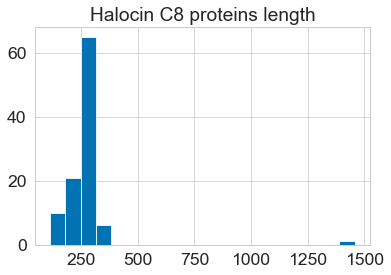

In [545]:
ax = gtdb_halc8_proteins['length'].hist(bins=20);
ax.set_title('Halocin C8 proteins length');

In [546]:
len(gtdb_halc8_proteins), len(gtdb_halc8_proteins[gtdb_halc8_proteins['length'] <= 500])

(103, 102)

In [547]:
records = []
for record in SeqIO.parse(halc8_out / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_candidates.fasta', 'fasta'):
    if record.id.split('-')[0] in gtdb_halc8_proteins.index:
        record.id = record.id.split('-')[0]
        records.append(record)

with (halc8_out / 'sequences' / 'gtdb_results' / 'GTDB_HalC8.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')

## Mapping

In [548]:
uni_map = pd.read_csv(staphc8_folder / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_UniprotKB_map.tsv', sep='\t')

uni_map['coverage'] = uni_map.apply(
    lambda row: np.round(
        100 * min(row['qlen'], row['tlen']) / max(row['qlen'], row['tlen']), 
        3,
    ), 
    axis=1,
)

perfect_match_uniprot = uni_map[
    (uni_map['fident'] == 1) &
    (uni_map['coverage'] == 100)
].reset_index(drop=True)
print(f'Number of perfect matches vs UniProtKB: {len(perfect_match_uniprot):,} ({100 * len(perfect_match_uniprot) / len(uni_map):.0f} %)')

Number of perfect matches vs UniProtKB: 43 (69 %)


In [549]:
db_proka_map = pd.read_csv(staphc8_folder / 'sequences' / 'gtdb_results' / 'GTDB_HalC8_db_proka_map.tsv', sep='\t')

db_proka_map['coverage'] = db_proka_map.apply(
    lambda row: np.round(
        100 * min(row['qlen'], row['tlen']) / max(row['qlen'], row['tlen']), 
        3,
    ), 
    axis=1,
)

perfect_match_db_proka = db_proka_map[
    (db_proka_map['fident'] == 1) &
    (db_proka_map['coverage'] == 100)
].reset_index(drop=True)
print(f'Number of perfect matches vs db_proka: {len(perfect_match_db_proka):,} ({100 * len(perfect_match_db_proka) / len(db_proka_map):.0f} %)')

Number of perfect matches vs db_proka: 49 (70 %)


In [550]:
gtdb_halc8_proteins['uniprot_id'] = None
for tpl in perfect_match_uniprot.itertuples():
    gtdb_halc8_proteins.loc[tpl.query, 'uniprot_id'] = tpl.target

gtdb_halc8_proteins.head()

,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,length,uniprot_id
protein_id,,,,,,,,,
AOIR01000031.1_72,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,273,None
AOIR01000038.1_26,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,298,None
ATMD01000005.1_21,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,206,None
CALTXP010000111.1_2,Bacteria,Bacillota A,Clostridia,Tissierellales,Peptoniphilaceae,Anaerococcus,Anaerococcus sp943913325,244,A0A0H2VGU6
CALUAK010000087.1_2,Bacteria,Actinomycetota,Actinomycetia,Mycobacteriales,Mycobacteriaceae,Corynebacterium,Corynebacterium sp943914015,122,None


In [551]:
gtdb_halc8_proteins['db_proka_id'] = None
for tpl in perfect_match_db_proka.itertuples():
    gtdb_halc8_proteins.loc[tpl.query, 'db_proka_id'] = tpl.target

gtdb_halc8_proteins.head()

,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,length,uniprot_id,db_proka_id
protein_id,,,,,,,,,,
AOIR01000031.1_72,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,273,None,ELZ16389.1@GCA_000337115.1
AOIR01000038.1_26,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,298,None,None
ATMD01000005.1_21,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,206,None,None
CALTXP010000111.1_2,Bacteria,Bacillota A,Clostridia,Tissierellales,Peptoniphilaceae,Anaerococcus,Anaerococcus sp943913325,244,A0A0H2VGU6,WP_002456424.1@GCF_006742205.1
CALUAK010000087.1_2,Bacteria,Actinomycetota,Actinomycetia,Mycobacteriales,Mycobacteriaceae,Corynebacterium,Corynebacterium sp943914015,122,None,None


In [552]:
interpro_map = {
    r.id.split('|')[0]: r
    for r in SeqIO.parse(staphc8_folder / 'sequences' / 'protein-matching-IPR031033-HalC8.fasta', 'fasta')
}
len(interpro_map)

155

In [553]:
len(set(interpro_map.keys()) - set(gtdb_halc8_proteins['uniprot_id'].unique()))

116

In [554]:
uniprot_ids_to_fetch = sorted(set(interpro_map.keys()) | set(gtdb_halc8_proteins[gtdb_halc8_proteins['uniprot_id'].notnull()]['uniprot_id'].unique()))

In [555]:
do_run = False
uniprot_metadata_path = halc8_out / 'sequences' / 'gtdb_results' / 'uniprot_metadata.csv'
if do_run:
    import requests
    import io

    # Construct the query part of the URL
    query = " OR ".join([f"(accession:{id})" for id in uniprot_ids_to_fetch])

    # Define the URL for the API request
    url = (
        "https://rest.uniprot.org/uniprotkb/search"
        f"?compressed=false&fields=accession%2Creviewed%2Cid%2Cprotein_name%2Cgene_names%2Corganism_name%2Clength%2Clineage&format=tsv&query=({query})&size=500"
    )

    # Make the request to the UniProt API
    response = requests.get(url)

    # Check if the request was successful
    if response.status_code == 200:
        # Parse the response text
        data = response.text

        # Convert the data to a DataFrame
        uniprot_metadata = pd.read_csv(io.StringIO(data), sep='\t')
        uniprot_metadata.to_csv(uniprot_metadata_path, index=False)
    else:
        print(f"Failed to fetch data: {response.status_code}")
else:
    uniprot_metadata = pd.read_csv(uniprot_metadata_path)

uniprot_metadata.head()

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Taxonomic lineage
0,P83716,reviewed,HAC8_HALAS,Pre-protein-C8 [Cleaved into: Immunity protein...,proC8,Halobacterium sp. (strain AS7092),283.0,"cellular organisms (no rank), Archaea (superki..."
1,A0A075WFM8,unreviewed,A0A075WFM8_ARCFL,Firmicute eSAT-6 protein secretion system EssA,AFULGI_00018220,Archaeoglobus fulgidus DSM 8774,308.0,"cellular organisms (no rank), Archaea (superki..."
2,A0A0K0KFP1,unreviewed,A0A0K0KFP1_9EURY,Halocin C8,proC8,Natrinema sp. SI14,283.0,"cellular organisms (no rank), Archaea (superki..."
3,A0A0K0KFQ3,unreviewed,A0A0K0KFQ3_9EURY,Halocin C8,proC8,Natrinema sp. SSI9,275.0,"cellular organisms (no rank), Archaea (superki..."
4,A0A1W6ALC8,unreviewed,A0A1W6ALC8_9EURY,Halocin C8,halC8,Natrinema altunense,283.0,"cellular organisms (no rank), Archaea (superki..."


In [556]:
uniprot_metadata['domain'] = uniprot_metadata['Taxonomic lineage'].apply(
    lambda v: v.split(', ')[1].strip().replace(' (superkingdom)', '') if not pd.isnull(v) else 'Bacteria'
)
uniprot_metadata.head()

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Taxonomic lineage,domain
0,P83716,reviewed,HAC8_HALAS,Pre-protein-C8 [Cleaved into: Immunity protein...,proC8,Halobacterium sp. (strain AS7092),283.0,"cellular organisms (no rank), Archaea (superki...",Archaea
1,A0A075WFM8,unreviewed,A0A075WFM8_ARCFL,Firmicute eSAT-6 protein secretion system EssA,AFULGI_00018220,Archaeoglobus fulgidus DSM 8774,308.0,"cellular organisms (no rank), Archaea (superki...",Archaea
2,A0A0K0KFP1,unreviewed,A0A0K0KFP1_9EURY,Halocin C8,proC8,Natrinema sp. SI14,283.0,"cellular organisms (no rank), Archaea (superki...",Archaea
3,A0A0K0KFQ3,unreviewed,A0A0K0KFQ3_9EURY,Halocin C8,proC8,Natrinema sp. SSI9,275.0,"cellular organisms (no rank), Archaea (superki...",Archaea
4,A0A1W6ALC8,unreviewed,A0A1W6ALC8_9EURY,Halocin C8,halC8,Natrinema altunense,283.0,"cellular organisms (no rank), Archaea (superki...",Archaea


In [557]:
uniprot_metadata = uniprot_metadata.set_index('Entry', drop=True)

In [558]:
gtdb_halc8_proteins['ncbi_organism_name'] = None

for protein_id in sorted(set(gtdb_halc8_proteins.index)):
    row = gtdb_halc8_proteins.loc[protein_id]

    if not pd.isnull(row['db_proka_id']):
        accession = row['db_proka_id'].split('@')[1]
        gtdb_halc8_proteins.loc[protein_id, 'ncbi_organism_name'] = gtdb_metadata.loc[accession, 'ncbi_organism_name']
    elif not pd.isnull(row['uniprot_id']):
        gtdb_halc8_proteins.loc[protein_id, 'ncbi_organism_name'] = uniprot_metadata.loc[row['uniprot_id'], 'Organism']
    
gtdb_halc8_proteins.head()

,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,length,uniprot_id,db_proka_id,ncbi_organism_name
protein_id,,,,,,,,,,,
AOIR01000031.1_72,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,273,None,ELZ16389.1@GCA_000337115.1,Haloterrigena thermotolerans DSM 11552
AOIR01000038.1_26,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,298,None,None,None
ATMD01000005.1_21,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,206,None,None,None
CALTXP010000111.1_2,Bacteria,Bacillota A,Clostridia,Tissierellales,Peptoniphilaceae,Anaerococcus,Anaerococcus sp943913325,244,A0A0H2VGU6,WP_002456424.1@GCF_006742205.1,Staphylococcus epidermidis
CALUAK010000087.1_2,Bacteria,Actinomycetota,Actinomycetia,Mycobacteriales,Mycobacteriaceae,Corynebacterium,Corynebacterium sp943914015,122,None,None,None


In [559]:
gtdb_halc8_proteins['source'] = gtdb_halc8_proteins['db_proka_id'].apply(
    lambda v: 'DB prokaryotes (GTDB 214 subset)' if not pd.isnull(v) else 'Wider GTDB 214'
)
gtdb_halc8_proteins['gtdb_id'] = gtdb_halc8_proteins.index

## Merge GTDB & UniProtKB fasta and metadata

In [560]:
columns = [
    'protein_id', 'uniprot_id', 'gtdb_id', 'db_proka_id',
    'domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_genus', 'gtdb_species', 'ncbi_organism_name',
    'length', 'source',
]

In [561]:
uniprot_no_gtdb = uniprot_metadata.loc[
    sorted(set(uniprot_metadata.index) - set(gtdb_halc8_proteins['uniprot_id'].unique()))
].reset_index().rename(columns={
    'Entry': 'protein_id',
    'Organism': 'ncbi_organism_name',
    'Length': 'length',
})
uniprot_no_gtdb['db_proka_id'] = None
uniprot_no_gtdb['gtdb_id'] = None
uniprot_no_gtdb['uniprot_id'] = uniprot_no_gtdb['protein_id']
uniprot_no_gtdb['gtdb_phylum'] = None
uniprot_no_gtdb['gtdb_class'] = None
uniprot_no_gtdb['gtdb_order'] = None
uniprot_no_gtdb['gtdb_family'] = None
uniprot_no_gtdb['gtdb_class'] = None
uniprot_no_gtdb['gtdb_genus'] = None
uniprot_no_gtdb['gtdb_species'] = None
uniprot_no_gtdb['source'] = 'UniProt'
uniprot_no_gtdb = uniprot_no_gtdb[columns].copy()
print(len(uniprot_no_gtdb))
uniprot_no_gtdb.head()

116


,protein_id,uniprot_id,gtdb_id,db_proka_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,length,source
0,A0A075WFM8,A0A075WFM8,None,None,Archaea,None,None,None,None,None,None,Archaeoglobus fulgidus DSM 8774,308.0,UniProt
1,A0A0K0KFP1,A0A0K0KFP1,None,None,Archaea,None,None,None,None,None,None,Natrinema sp. SI14,283.0,UniProt
2,A0A0K0KFP9,A0A0K0KFP9,None,None,Archaea,None,None,None,None,None,None,Natrinema sp. SWI15,283.0,UniProt
3,A0A0K0KFQ3,A0A0K0KFQ3,None,None,Archaea,None,None,None,None,None,None,Natrinema sp. SSI9,275.0,UniProt
4,A0A0K0KFY8,A0A0K0KFY8,None,None,Archaea,None,None,None,None,None,None,Natrinema sp. SI4,283.0,UniProt


In [562]:
all_halc8_proteins = pd.concat(
    [
        gtdb_halc8_proteins.reset_index()[columns],
        uniprot_no_gtdb,

    ],
    ignore_index=True,
).rename(columns={
    'protein_id': 'id',
})

all_halc8_proteins = all_halc8_proteins.set_index('id', drop=True)

assert len(all_halc8_proteins.index) == len(set(all_halc8_proteins.index))

print(f'Number of proteins: {len(all_halc8_proteins):,}')
all_halc8_proteins.head()

Number of proteins: 219


,uniprot_id,gtdb_id,db_proka_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,length,source
id,,,,,,,,,,,,,
AOIR01000031.1_72,None,AOIR01000031.1_72,ELZ16389.1@GCA_000337115.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,Haloterrigena thermotolerans DSM 11552,273.0,DB prokaryotes (GTDB 214 subset)
AOIR01000038.1_26,None,AOIR01000038.1_26,None,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,None,298.0,Wider GTDB 214
ATMD01000005.1_21,None,ATMD01000005.1_21,None,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,None,206.0,Wider GTDB 214
CALTXP010000111.1_2,A0A0H2VGU6,CALTXP010000111.1_2,WP_002456424.1@GCF_006742205.1,Bacteria,Bacillota A,Clostridia,Tissierellales,Peptoniphilaceae,Anaerococcus,Anaerococcus sp943913325,Staphylococcus epidermidis,244.0,DB prokaryotes (GTDB 214 subset)
CALUAK010000087.1_2,None,CALUAK010000087.1_2,None,Bacteria,Actinomycetota,Actinomycetia,Mycobacteriales,Mycobacteriaceae,Corynebacterium,Corynebacterium sp943914015,None,122.0,Wider GTDB 214


In [563]:
all_halc8_proteins.loc['CALTXP010000111.1_2', 'db_proka_id'] = None
all_halc8_proteins.loc['CALTXP010000111.1_2', 'uniprot_id'] = None

all_halc8_proteins.loc['CP002989.1_262', 'db_proka_id'] = None

all_halc8_proteins.loc['NZ_FOXI01000014.1_10', 'uniprot_id'] = None

In [564]:
len(all_halc8_proteins[
    all_halc8_proteins['db_proka_id'].notnull() &
    all_halc8_proteins['db_proka_id'].duplicated()
]) == 0

True

In [565]:
len(all_halc8_proteins[
    all_halc8_proteins['uniprot_id'].notnull() &
    all_halc8_proteins['uniprot_id'].duplicated()
]) == 0

True

In [566]:
len(all_halc8_proteins[
    all_halc8_proteins['gtdb_id'].notnull() &
    all_halc8_proteins['gtdb_id'].duplicated()
]) == 0

True

### Sources breakdown

In [567]:
all_halc8_proteins['source'].value_counts()

UniProt                             116
Wider GTDB 214                       54
DB prokaryotes (GTDB 214 subset)     49
Name: source, dtype: int64

Looks like we are missing a bunch of entries from DB proka, let's add them.

In [568]:
halocins_c8_df = halocins_df[halocins_df['amp_id'] == 'Halocin_C8'].copy()
len(halocins_c8_df)

81

In [569]:
halocins_c8_df['db_proka_id'] = halocins_c8_df.apply(lambda row: f'{row["protein_id"]}@{row["assembly_accession"]}', axis=1)
halocins_c8_df.head()

,assembly_accession,protein_id,amp_id,amp_desc,evalue,bitscore,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,uniprot_id,db_proka_id
225,GCA_000224475.1,AEN07551.1,Halocin_C8,TIGR04449,2.800000e-13,48.3,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halolamina,Halolamina sp000224475,halophilic archaeon DL31,NaN,AEN07551.1@GCA_000224475.1
356,GCA_000337115.1,ELZ16389.1,Halocin_C8,TIGR04449,1.900000e-12,45.8,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,Haloterrigena thermotolerans DSM 11552,NaN,ELZ16389.1@GCA_000337115.1
964,GCA_000690595.2,OAQ51225.1,Halocin_C8,TIGR04449,4.900000e-16,57.3,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema mahii,Haloterrigena mahii,NaN,OAQ51225.1@GCA_000690595.2
3657,GCA_001856825.1,EQB64365.1,Halocin_C8,TIGR04449,5.300000e-15,52.8,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,Thermoplasmatales archaeon I-plasma,NaN,EQB64365.1@GCA_001856825.1
10072,GCA_002498845.1,DAJC01000023.1_20,Halocin_C8,TIGR04449,2.700000e-11,41.1,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,Thermoplasmataceae,UBA509,UBA509 sp002498845,Thermoplasmatales archaeon UBA509,NaN,DAJC01000023.1_20@GCA_002498845.1


In [570]:
halocins_c8_df['gtdb_id'] = None
halocins_c8_df['length'] = 0
halocins_c8_df['source'] = 'DB prokaryotes (GTDB 214 subset)'
halocins_c8_df['id'] = halocins_c8_df['db_proka_id']

halocins_c8_db_proka = halocins_c8_df[[
    'id', 'uniprot_id', 'gtdb_id', 'db_proka_id',
    'domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_genus', 'gtdb_species', 'ncbi_organism_name',
    'length', 'source',
]].set_index('id', drop=True)

db_proka_new = set(halocins_c8_db_proka['db_proka_id'].unique()) - set(all_halc8_proteins['db_proka_id'].unique())

db_proka_sequences_path = staphc8_folder / 'sequences' / 'gtdb_results' / 'HalC8_db_proka.fasta'
db_proka_sequences = []
for record in SeqIO.parse(db_proka_sequences_path, 'fasta'):
    if record.seq.endswith('*'):
        record.seq = record.seq[:-1]

    if record.id in db_proka_new:
        length = len(record.seq)
        halocins_c8_db_proka.loc[record.id, 'length'] = length
        species = halocins_c8_db_proka.loc[record.id, 'gtdb_species'].replace(' ', '_')

        record.id = f'{record.id}${species}'
        record.name = ''
        record.description = ''

        db_proka_sequences.append(record)

halocins_c8_db_proka.head()

,uniprot_id,gtdb_id,db_proka_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,length,source
id,,,,,,,,,,,,,
AEN07551.1@GCA_000224475.1,NaN,None,AEN07551.1@GCA_000224475.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halolamina,Halolamina sp000224475,halophilic archaeon DL31,296,DB prokaryotes (GTDB 214 subset)
ELZ16389.1@GCA_000337115.1,NaN,None,ELZ16389.1@GCA_000337115.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema thermotolerans,Haloterrigena thermotolerans DSM 11552,0,DB prokaryotes (GTDB 214 subset)
OAQ51225.1@GCA_000690595.2,NaN,None,OAQ51225.1@GCA_000690595.2,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Natrialbaceae,Natrinema,Natrinema mahii,Haloterrigena mahii,0,DB prokaryotes (GTDB 214 subset)
EQB64365.1@GCA_001856825.1,NaN,None,EQB64365.1@GCA_001856825.1,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,GCA-001856825,GCA-001856825,GCA-001856825 sp001856825,Thermoplasmatales archaeon I-plasma,215,DB prokaryotes (GTDB 214 subset)
DAJC01000023.1_20@GCA_002498845.1,NaN,None,DAJC01000023.1_20@GCA_002498845.1,Archaea,Thermoplasmatota,Thermoplasmata,Thermoplasmatales,Thermoplasmataceae,UBA509,UBA509 sp002498845,Thermoplasmatales archaeon UBA509,203,DB prokaryotes (GTDB 214 subset)


In [571]:
if len(db_proka_new) > 0:
    all_halc8_proteins = pd.concat(
        [
            halocins_c8_db_proka.loc[sorted(db_proka_new)].reset_index(),
            all_halc8_proteins.reset_index(),
        ],
        ignore_index=True,
    ).set_index('id', drop=True)

len(all_halc8_proteins)

253

### Re-jingle main ID

UniProt ID takes priority when available, followed by DB proka ID.

In [572]:
def set_id(row):
    if not pd.isnull(row['uniprot_id']):
        return row['uniprot_id']
    elif not pd.isnull(row['db_proka_id']):
        return row['db_proka_id']
    elif not pd.isnull(row['gtdb_id']):
        return row['gtdb_id']
    else:
        raise ValueError(f'No ID available: {row.name} | {row["ncbi_organism_name"]}')


all_halc8_proteins = all_halc8_proteins.reset_index()
all_halc8_proteins['id'] = all_halc8_proteins.apply(set_id, axis=1)
all_halc8_proteins = all_halc8_proteins.set_index('id', drop=True)

### Export final dataset

In [573]:
all_records = db_proka_sequences
seen_ids = set()
gtdb_ids = set(all_halc8_proteins['gtdb_id'].unique())
for record in SeqIO.parse(halc8_out / 'sequences' / 'gtdb_results' / 'GTDB_HalC8.fasta', 'fasta'):
    if record.id in gtdb_ids:
        df = all_halc8_proteins[all_halc8_proteins['gtdb_id'] == record.id]
        assert len(df) == 1, record.id
        row = df.iloc[0]
        species = row['gtdb_species'].replace(' ', '_')
        record.id = f'{row.name}${species}'
        record.name = ''
        record.description = ''
        all_records.append(record)
        seen_ids.add(row.name)

ids_set = set()
for record in SeqIO.parse(staphc8_folder / 'sequences' / 'protein-matching-IPR031033-HalC8.fasta', 'fasta'):
    naked_id = record.id.split('|')[0]
    if naked_id in all_halc8_proteins.index and naked_id not in seen_ids:
        species = all_halc8_proteins.loc[naked_id, 'ncbi_organism_name'].replace(' ', '_')
        record.id = f'{naked_id}${species}'
        record.name = ''
        record.description = ''
        all_records.append(record)

print(f'Final number of records: {len(all_records):,}')

assert len(all_records) == len(all_halc8_proteins)

all_halc8_proteins.sort_values([
    'domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order',  'gtdb_family', 'gtdb_genus', 
    'gtdb_species', 'ncbi_organism_name', 'uniprot_id', 'db_proka_id', 'gtdb_id',
]).to_csv(halc8_out / 'sequences' / 'HalC8_proteins.csv')

with (halc8_out / 'sequences' / 'HalC8_proteins.fasta').open('w') as f_out:
    SeqIO.write(all_records, f_out, 'fasta')

Final number of records: 253


In [574]:
all_halc8_proteins['source'].value_counts()

UniProt                             116
DB prokaryotes (GTDB 214 subset)     83
Wider GTDB 214                       54
Name: source, dtype: int64

## Create subset without proteins that are too long

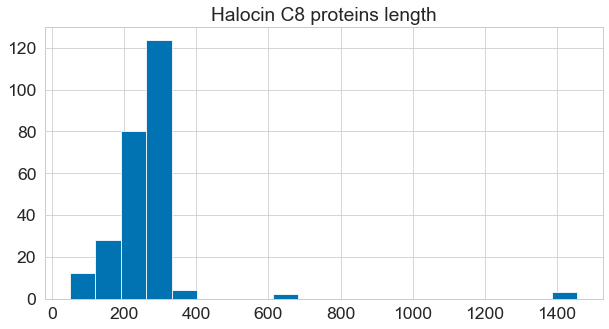

In [575]:
ax = all_halc8_proteins['length'].hist(bins=20, figsize=(10, 5));
ax.set_title('Halocin C8 proteins length');

In [584]:
above_500_aa = all_halc8_proteins[all_halc8_proteins['length'] > 500]
above_500_aa

,uniprot_id,gtdb_id,db_proka_id,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,length,source
id,,,,,,,,,,,,,
WP_008479876.1@GCF_000297255.1,NaN,None,WP_008479876.1@GCF_000297255.1,Bacteria,Chloroflexota,Chloroflexia,Thermomicrobiales,Thermomicrobiaceae,Nitrolancea,Nitrolancea hollandica,Nitrolancea hollandica Lb,1438.0,DB prokaryotes (GTDB 214 subset)
WP_135825305.1@GCF_004765785.1,NaN,None,WP_135825305.1@GCF_004765785.1,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Halorussus,Halorussus ruber,Halorussus ruber,681.0,DB prokaryotes (GTDB 214 subset)
WP_135854137.1@GCF_004765815.2,NaN,None,WP_135854137.1@GCF_004765815.2,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haladaptataceae,Halorussus,Halorussus salinus,Halorussus salinus,680.0,DB prokaryotes (GTDB 214 subset)
NZ_CAGS01000400.1_2,None,NZ_CAGS01000400.1_2,None,Bacteria,Chloroflexota,Chloroflexia,Thermomicrobiales,Thermomicrobiaceae,Nitrolancea,Nitrolancea hollandica,None,1457.0,Wider GTDB 214
I4EKF2,I4EKF2,None,None,Bacteria,None,None,None,None,None,None,Nitrolancea hollandica Lb,1438.0,UniProt


In [585]:
subset_records = [r for r in all_records if r.id.split('$')[0] not in above_500_aa.index]
len(subset_records) == len(all_halc8_proteins) - len(above_500_aa)

True

In [586]:
len(subset_records)

248

In [587]:
with (halc8_out / 'sequences' / 'HalC8_proteins_lt_500aa.fasta').open('w') as f_out:
    SeqIO.write(subset_records, f_out, 'fasta')

## Tree annotations

In [589]:
tree_path = staphc8_folder / 'tree' / 'HalC8.treefile'
halc8_tree = Phylo.read(tree_path, 'newick')

In [598]:
labels_data = []
halc8_domains_data = []
domain_color = {
    'Archaea': palette[1],  # orange
    'Bacteria': palette[0], # blue
}
for leaf in halc8_tree.get_terminals():
    protein_id = leaf.name.replace('_GC', '@GC')
    row = all_halc8_proteins.loc[protein_id]
    
    domain = row['domain']
    species = row['gtdb_species']
    if pd.isnull(species):
        species = row['ncbi_organism_name']

    label = f'{species} [{protein_id}]'

    labels_data.append([
        leaf.name,
        label,
    ])

    halc8_domains_data.append([
        leaf.name,
        domain_color[domain],
        domain,
    ])

itol_labels(
    labels_data,
    output_path=halc8_out / 'tree' / 'annotations' / 'halc8_labels.txt',
)

itol_color_strip_annotations(
    halc8_domains_data,
    output_path=halc8_out / 'tree' / 'annotations' / 'halc8_domains.txt',
    dataset_label='Domain',
    legend_title='Domain',
    color_branches=True,
)